In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [6]:
df=pd.read_csv('train.csv')

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [4]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


C:\Users\Admin\AppData\Local\Temp\ipykernel_18012\1213281828.py:1: FutureWarning: Parsed string "Mon Apr 06 22:19:45 PDT 2009" included an un-recognized timezone "PDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  df['date']=pd.to_datetime(df['date'])


,sentiment,id,date,query,user,text
0,0,1467810369,2009-04-06 22:19:45,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,2009-04-06 22:19:49,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,2009-04-06 22:19:53,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,2009-04-06 22:19:57,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,2009-04-06 22:19:57,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [12]:
df.isnull().sum()

id            0
keyword       0
location      0
text          0
target        0
clean_text    0
dtype: int64

In [11]:
df=df.dropna(subset=['location'])

In [13]:
df['clean_text']=df['text'].str.lower()

C:\Users\Admin\AppData\Local\Temp\ipykernel_33532\1697332450.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_text']=df['text'].str.lower()


In [14]:
df['hashtags']=df['clean_text'].apply(lambda x:re.findall(r"#\w+",str(x).lower()))

C:\Users\Admin\AppData\Local\Temp\ipykernel_33532\476355172.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hashtags']=df['clean_text'].apply(lambda x:re.findall(r"#\w+",str(x).lower()))


In [15]:
all_hashtags=[tag for tags in df['hashtags'] for tag in tags]

In [16]:
hashtag_counts=pd.Series(all_hashtags).value_counts()

In [17]:
print(hashtag_counts.head(10))

#news          39
#hot           25
#best          25
#prebreak      25
#nowplaying    21
#gbbo          17
#jobs          14
#hiroshima     14
#earthquake    14
#job           12
Name: count, dtype: int64


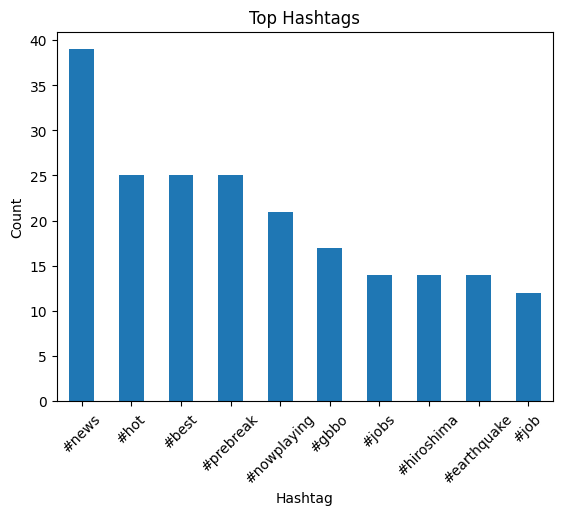

In [18]:
hashtag_counts.head(10).plot(kind='bar')
plt.title("Top Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

<Axes: ylabel='count'>

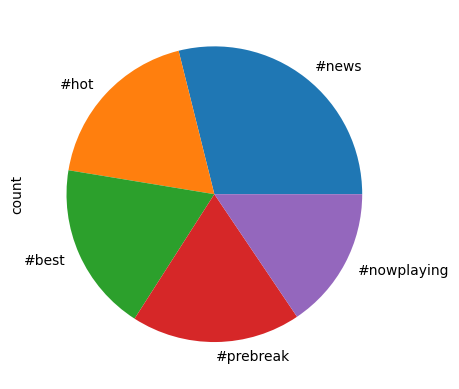

In [19]:
hashtag_counts.head(5).plot(kind='pie')

<Axes: >

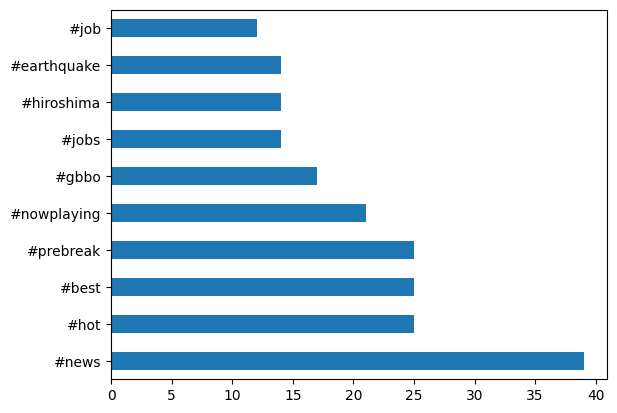

In [20]:
hashtag_counts.head(10).plot(kind='barh')

<Axes: xlabel='count'>

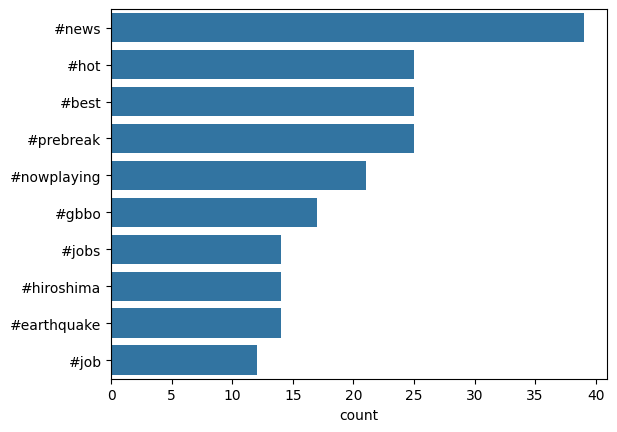

In [22]:
sns.countplot(y=all_hashtags,order=hashtag_counts.index[:10])

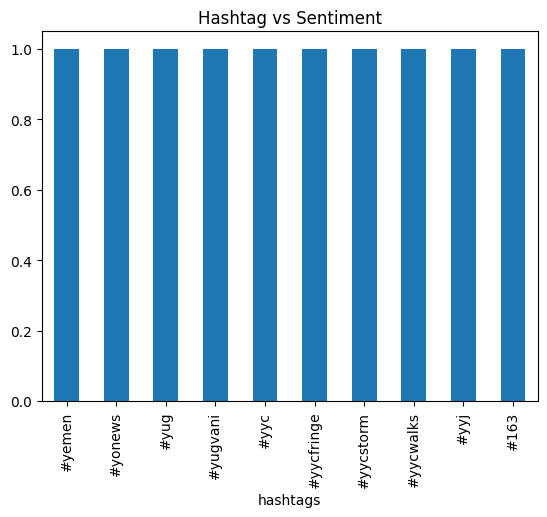

In [ ]:
df_exploded = df.explode('hashtags')

sentiment_counts = df_exploded.groupby('hashtags')['target'].mean()

sentiment_counts.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Hashtag vs Sentiment")
plt.show()